# Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.ticker as mticks
import matplotlib.dates as mdates
import glob
import statsmodels.tsa.api as tsa
plt.rcParams['figure.figsize'] = (12,4)
plt.rcParams['figure.facecolor'] = 'white'
sns.set_context("talk", font_scale=0.9)
SEED = 42
np.random.seed(SEED)
pd.set_option('display.max_columns',50)



In [ ]:
df = pd.read_csv("C:/Users/Yousef/Desktop/Data_Science/Data/Chicago-Crime_All.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7713109 entries, 0 to 7713108
Data columns (total 12 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Date                  object 
 2   Primary Type          object 
 3   Description           object 
 4   Location Description  object 
 5   Arrest                bool   
 6   Domestic              bool   
 7   Beat                  int64  
 8   District              float64
 9   Ward                  float64
 10  Latitude              float64
 11  Longitude             float64
dtypes: bool(2), float64(4), int64(2), object(4)
memory usage: 603.2+ MB


In [ ]:
print(df.duplicated(subset='ID').sum())

0


In [ ]:
df['Date'] = pd.to_datetime(df['Date'],errors='coerce')

In [ ]:
df.isna().sum()

ID                           0
Date                         0
Primary Type                 0
Description                  0
Location Description     10928
Arrest                       0
Domestic                     0
Beat                         0
District                    47
Ward                    614846
Latitude                 88685
Longitude                88685
dtype: int64

In [ ]:
df = df.set_index('Date')
df = df.sort_index()
df.head()

,ID,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
Date,,,,,,,,,,,
2001-01-01,3214584,THEFT,FINANCIAL ID THEFT: OVER $300,STREET,False,False,2221,22.0,21.0,41.732563,-87.669923
2001-01-01,1927872,THEFT,AGG: FINANCIAL ID THEFT,RESIDENCE,False,False,812,8.0,NaN,41.778094,-87.770137
2001-01-01,4768442,OFFENSE INVOLVING CHILDREN,SEX ASSLT OF CHILD BY FAM MBR,RESIDENCE,False,False,2124,2.0,4.0,41.807275,-87.593707
2001-01-01,2280620,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,False,915,9.0,20.0,41.806311,-87.674782
2001-01-01,9755214,SEX OFFENSE,AGG CRIMINAL SEXUAL ABUSE,CHURCH/SYNAGOGUE/PLACE OF WORSHIP,False,False,1022,10.0,24.0,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7713109 entries, 2001-01-01 00:00:00 to 2022-12-31 23:55:00
Data columns (total 11 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Primary Type          object 
 2   Description           object 
 3   Location Description  object 
 4   Arrest                bool   
 5   Domestic              bool   
 6   Beat                  int64  
 7   District              float64
 8   Ward                  float64
 9   Latitude              float64
 10  Longitude             float64
dtypes: bool(2), float64(4), int64(2), object(3)
memory usage: 603.2+ MB


## Comparing Police Districts

In [ ]:
df['Year'] = df.index.year
crime_2022 = df[df['Year'] == 2022]
crime_2022.head(3)

,ID,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude,Year
Date,,,,,,,,,,,,
2022-01-01,12701677,OTHER OFFENSE,HARASSMENT BY TELEPHONE,RESIDENCE,False,True,2413,24.0,40.0,41.994004,-87.697387,2022
2022-01-01,12615410,DECEPTIVE PRACTICE,"THEFT BY LESSEE, MOTOR VEHICLE",STREET,False,False,1235,12.0,25.0,41.852750,-87.640816,2022
2022-01-01,12658052,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,APARTMENT,False,False,511,5.0,8.0,41.717813,-87.598279,2022


In [ ]:
district_max = crime_2022['District'].value_counts().idxmax()
district_max_value = crime_2022['District'].value_counts().max()

In [ ]:
district_min = crime_2022['District'].value_counts().idxmin()
district_min_value = crime_2022['District'].value_counts().min()

In [ ]:
print(f"The district with the most crimes in 2022 is {district_max} with {district_max_value} crimes.")
print(f"The district with the least crimes in 2022 is {district_min} with {district_min_value} crimes.")

The district with the most crimes in 2022 is 8.0 with 14805 crimes.
The district with the least crimes in 2022 is 31.0 with 15 crimes.


## Crimes Across the Years

In [ ]:
crime_count = df['Year'].value_counts()
crime_count

Year
2002    486807
2001    485886
2003    475985
2004    469422
2005    453773
2006    448179
2007    437087
2008    427183
2009    392827
2010    370513
2011    351993
2012    336319
2013    307536
2014    275789
2016    269823
2017    269100
2018    268899
2015    264787
2019    261325
2022    238858
2020    212194
2021    208824
Name: count, dtype: int64

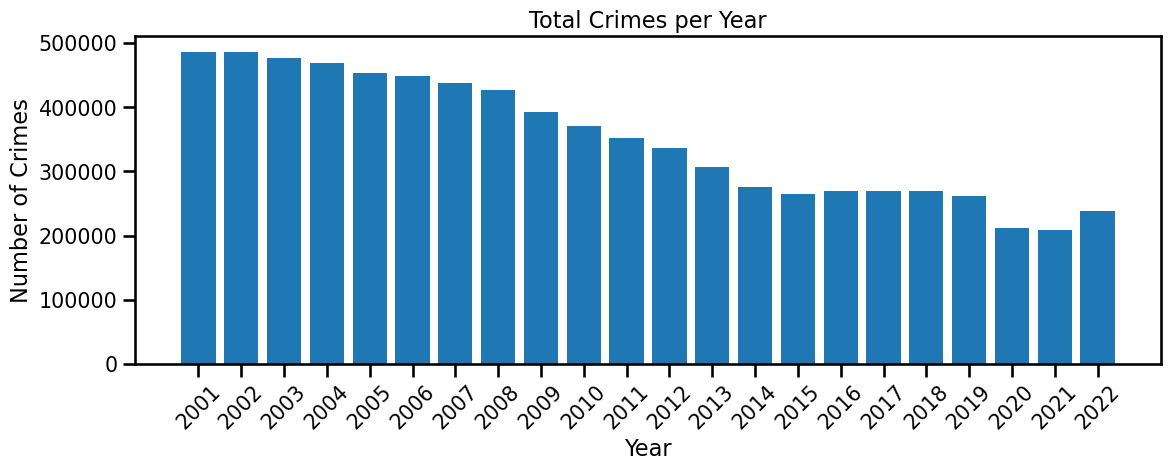

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(crime_count.index, crime_count.values)
ax.set_title('Total Crimes per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Crimes')
ax.set_xticks(crime_count.index)
ax.set_xticklabels(crime_count.index, rotation=45)
fig.tight_layout()

In [ ]:
if crime_count.diff().sum() > 0:
    overall_trend = "increasing"
else:
    overall_trend = "decreasing"

print(f"Crime in Chicago has been {overall_trend} over the years.")

Crime in Chicago has been decreasing over the years.


In [ ]:
crime_by_type = df.groupby(['Year', 'Primary Type']).size().unstack()

increasing_crimes = []
decreasing_crimes = []

for crime in crime_by_type.columns:
    trend = crime_by_type[crime].diff().sum()
    if trend > 0:
        increasing_crimes.append(crime)
    else:
        decreasing_crimes.append(crime)

In [ ]:
if overall_trend == "decreasing":
    print("\nCrimes going OPPOSITE to the overall trend (increasing while overall is decreasing):")
    for crime in increasing_crimes:
        print(f"  * {crime}")
else:
    print("\nCrimes going OPPOSITE to the overall trend (decreasing while overall is increasing):")
    for crime in decreasing_crimes:
        print(f"  * {crime}")


Crimes going OPPOSITE to the overall trend (increasing while overall is decreasing):
  * CONCEALED CARRY LICENSE VIOLATION
  * CRIMINAL SEXUAL ASSAULT
  * DECEPTIVE PRACTICE
  * HOMICIDE
  * HUMAN TRAFFICKING
  * NON - CRIMINAL
  * NON-CRIMINAL (SUBJECT SPECIFIED)
  * OBSCENITY
  * OTHER NARCOTIC VIOLATION
  * STALKING
  * WEAPONS VIOLATION


## Comparing AM vs. PM Rush Hour

In [ ]:
df['Hour'] = df.index.hour

am_rush = df[(df['Hour'] >= 7) & (df['Hour'] < 10)]
pm_rush = df[(df['Hour'] >= 16) & (df['Hour'] < 19)]

In [ ]:
print(f"AM Rush Hour crimes: {am_rush.shape[0]}")
print(f"PM Rush Hour crimes: {pm_rush.shape[0]}")

AM Rush Hour crimes: 770651
PM Rush Hour crimes: 1206353


In [ ]:
# Top 5 crimes each
print("\nTop 5 AM Rush Hour Crimes:")
print(am_rush['Primary Type'].value_counts(ascending=False).head())

print("\nTop 5 PM Rush Hour Crimes:")
print(pm_rush['Primary Type'].value_counts(ascending=False).head())


Top 5 AM Rush Hour Crimes:
Primary Type
THEFT              185239
BATTERY            108199
CRIMINAL DAMAGE     81281
BURGLARY            73999
OTHER OFFENSE       62453
Name: count, dtype: int64

Top 5 PM Rush Hour Crimes:
Primary Type
THEFT              293514
BATTERY            213002
CRIMINAL DAMAGE    134101
NARCOTICS          103032
ASSAULT             89600
Name: count, dtype: int64


In [ ]:
# Motor Vehicle Theft
am_mv = am_rush[am_rush['Primary Type'] == 'MOTOR VEHICLE THEFT'].shape[0]
pm_mv = pm_rush[pm_rush['Primary Type'] == 'MOTOR VEHICLE THEFT'].shape[0]

if am_mv > am_mv:
    print(f"Motor Vehicle Theft is more common during AM Rush Hour ({am_mv} vs {pm_mv})")
else:
    print(f"Motor Vehicle Theft is more common during PM Rush Hour ({pm_mv} vs {am_mv})")

Motor Vehicle Theft is more common during PM Rush Hour (53716 vs 41578)


## Comparing Months

In [ ]:
df['Month'] = df.index.month

month_count = df['Month'].value_counts()
month_count

Month
7     717232
8     710444
5     682932
6     681739
10    676285
9     668242
3     629704
4     627175
11    608961
1     601236
12    579768
2     529391
Name: count, dtype: int64

In [ ]:
most_crime_month = month_count.idxmax()
least_crime_month = month_count.idxmin()

In [ ]:
print(f"Month with most crimes: {most_crime_month}")
print(f"Month with least crimes: {least_crime_month}")

Month with most crimes: 7
Month with least crimes: 2


In [ ]:
monthly_by_type = df.groupby(['Month', 'Primary Type']).size().unstack()


opposite_crimes = []
for crime in monthly_by_type.columns:
    crime_peak = monthly_by_type[crime].idxmax()
    if crime_peak == least_crime_month:
        opposite_crimes.append(crime)


print("Crimes that peak in the lowest crime month:")
for crime in opposite_crimes:
    print(f"  * {crime}")

Crimes that peak in the lowest crime month:
  * NON-CRIMINAL (SUBJECT SPECIFIED)


## Comparing Holidays

In [ ]:
!pip install holidays

In [ ]:
import holidays
from holidays import country_holidays

us_holidays = country_holidays('US')
df["US Holiday"] = [us_holidays.get(day) for day in df.index]

In [ ]:
holiday_df = df[df['US Holiday'].notna()]
top3_holiday_crime = holiday_df.groupby('US Holiday').size().sort_values(ascending=False).head(3)
print(top3_holiday_crime)

US Holiday
New Year's Day      32725
Independence Day    22672
Labor Day           22164
dtype: int64


In [ ]:
for holiday in top3_holiday_crime.index:
    print(f"\nTop 5 crimes on {holiday}:")
    top5 = holiday_df[holiday_df['US Holiday'] == holiday]['Primary Type'].value_counts().head()
    print(top5)


Top 5 crimes on New Year's Day:
Primary Type
THEFT                         6845
BATTERY                       6043
CRIMINAL DAMAGE               3236
DECEPTIVE PRACTICE            2934
OFFENSE INVOLVING CHILDREN    2380
Name: count, dtype: int64

Top 5 crimes on Independence Day:
Primary Type
BATTERY            5805
THEFT              4074
CRIMINAL DAMAGE    3309
ASSAULT            1547
NARCOTICS          1522
Name: count, dtype: int64

Top 5 crimes on Labor Day:
Primary Type
BATTERY            4607
THEFT              4520
CRIMINAL DAMAGE    2475
NARCOTICS          2078
ASSAULT            1525
Name: count, dtype: int64


## Seasonality

In [ ]:
crimes_ts = df.groupby(['Date', 'Primary Type']).size().unstack(fill_value=0)

crimes_ts_month = crimes_ts.resample('M').sum()
total_crime_count = crimes_ts_month.sum(axis=1)

total_crime_count.head()

C:\Users\Yousef\AppData\Local\Temp\ipykernel_34428\4091082385.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  crimes_ts_month = crimes_ts.resample('M').sum()


Date
2001-01-31    38119
2001-02-28    33787
2001-03-31    40566
2001-04-30    40091
2001-05-31    41839
Freq: ME, dtype: int64

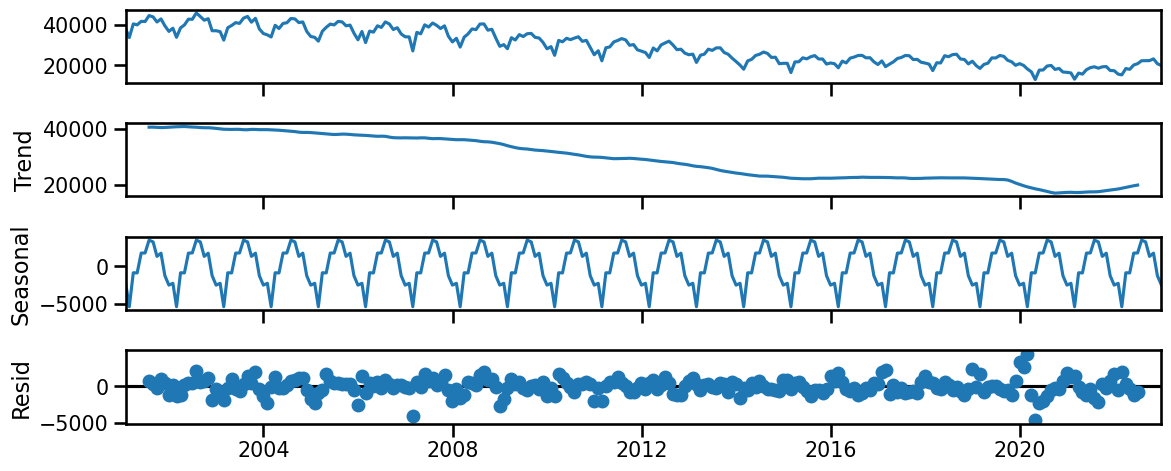

In [ ]:
decomp_crime = tsa.seasonal_decompose(total_crime_count, period=12)

fig = decomp_crime.plot()
fig.set_size_inches(12, 5)
fig.tight_layout()

In [ ]:
seasonal_zoomed = decomp_crime.seasonal['2017':'2020']

max_s = seasonal_zoomed.max()
min_s = seasonal_zoomed.min()
magnitude = max_s - min_s
max_ids = seasonal_zoomed.idxmax()
min_ids = seasonal_zoomed.idxmin()

In [ ]:
peaks, props = find_peaks(seasonal_zoomed, height=seasonal_zoomed.max())
peak_dates = seasonal_zoomed.index[peaks]
period = peak_dates[1] - peak_dates[0]

periods = []
for i in range(len(peak_dates)-1):
    delta = peak_dates[i+1] - peak_dates[i]
    periods.append(delta)

print("Calculated periods between peaks:", periods)

Calculated periods between peaks: [Timedelta('365 days 00:00:00'), Timedelta('365 days 00:00:00'), Timedelta('366 days 00:00:00')]


In [ ]:
def plot_seasonal(seasonal):
    minor_loc = mdates.MonthLocator()
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(seasonal, zorder=3)
    ax.set(title='Seasonal Component for crimes')

    ax.xaxis.set_minor_locator(minor_loc)
    ax.grid(which='major', axis='x', lw=1, color='k', zorder=2)
    ax.grid(which='minor', axis='x', lw=0.5, color='lightgrey', zorder=1)
    fig.autofmt_xdate(rotation=90, ha='center')

    return fig, ax

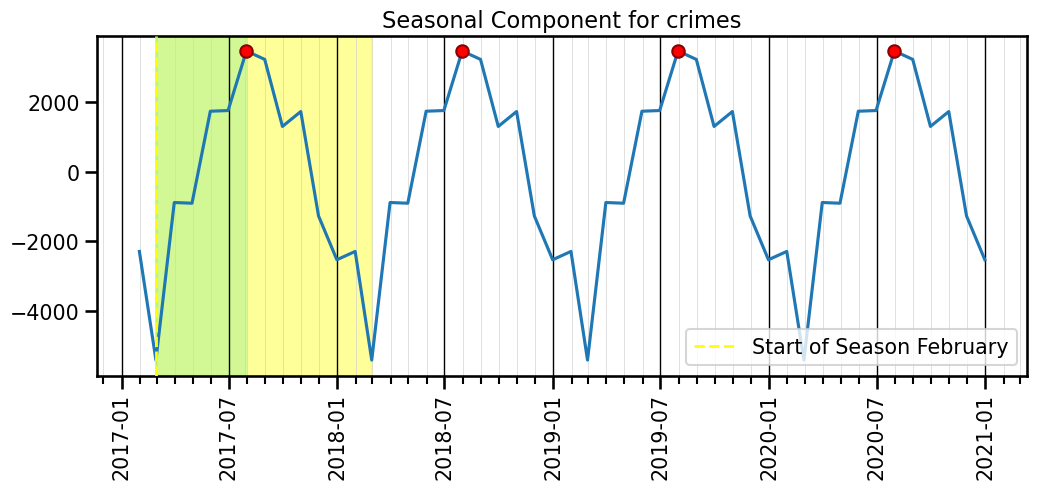

In [ ]:
fig, ax = plot_seasonal(seasonal_zoomed)
season_start = seasonal_zoomed.idxmin()

ax.axvspan(season_start, season_start + period, color='yellow', alpha=0.4, zorder=0)
ax.axvline(season_start, color='yellow', ls='--', lw=2,
           label=f"Start of Season {season_start.strftime('%B')}", zorder=4)
ax.scatter(peak_dates, props['peak_heights'], color='red', s=80, edgecolors='darkred', zorder=5)
ax.axvspan(seasonal_zoomed.idxmin(), seasonal_zoomed.idxmax(), color='lightgreen', alpha=0.4, zorder=0)

ax.legend(loc='lower right')

In [ ]:
print(f"1. How long is the cycle ? 365 days")
print(f"2. Maximum Seasonal Value: {max_s:.2f} , date: {max_ids.strftime('%Y-%m-%d')}")
print(f"3. Minimum Seasonal Value: {min_s:.2f} , date: {min_ids.strftime('%Y-%m-%d')}")
print(f"4. What is the magnitude of the cycle? {magnitude:.2f} crimes")

1. How long is the cycle ? 365 days
2. Maximum Seasonal Value: 3481.66 , date: 2017-07-31
3. Minimum Seasonal Value: -5416.09 , date: 2017-02-28
4. What is the magnitude of the cycle? 8897.74 crimes
